In [43]:
import pandas as pd
import matplotlib.pyplot as plt


csv_paths = [
    "2025_1.csv",
    "2025_0.csv"
]
dfs = []
for f in csv_paths:
    dfs.append(pd.read_csv(
        f,
        sep=";",                # semicolon separator
        quotechar='"',          # handle quoted fields properly
        decimal=",",            # interpret ',' as decimal
        engine="python",        # more forgiving parser
        dtype=str               # read everything as string first to avoid type issues
    ))
df = pd.concat(dfs, ignore_index=True)

In [44]:
category_map = {
    'Zdrowie': 
        ['Lekarstwa','Opieka medyczna'],
    'Transport': 
        ['Paliwo','Transport publiczny','Taxi','Bilety lotnicze'],
    'Odzież i dodatki': 
        ['Dodatki, biżuteria','Ubrania','Usługi (pralnia, krawiec, szewc,...)'],
    'Rachunki': 
        ['Czynsz','Internet, TV, telefon','Ubezpieczenia','Prąd'],
    'Dom': 
        ['Artykuły dekoracyjne','Naprawy i remonty','Wyposażenie','Sprzęt AGD i RTV','Ogród','Sprzątanie'],
    'Rozrywka i wypoczynek': 
        ['Restauracje i kawiarnie','Multimedia','Sport','Podróże','Puby i kluby','Gazety lub czasopisma','Kino i teatr','Hobby','Hotele','Książki'],
    'Wydatki bieżące': 
        ['Artykuły spożywcze','Kosmetyki','Zwierzęta domowe','Uroda, fryzjer, kosmetyczka','Fotografia','Zakupy przez internet','Alkohol','Papierosy'],
    'Dla innych': 
        ['Prezenty, upominki'],
    'Podatki i opłaty': 
        ['Opłaty bankowe'],
    'Obciążenia wewnętrzne': 
        ['Przelew wewnętrzny','Założenie lokaty, zakup funduszy, akcji'],
    'Inne': 
        ['Inne','Wypłata z bankomatu','Spłata kredytu / pożyczki','Wypłata z rachunku'],
    'Bez kategorii': 
        ['Bez kategorii']
}
reverse_map = {v:k for k,vals in category_map.items() for v in vals}

df["Nadkategoria"] = df["Kategoria"].map(reverse_map)  # .fillna("Bez kategorii")
df["Data księgowania"] = pd.to_datetime(df["Data księgowania"], dayfirst=True)
df["Miesiąc"] = df["Data księgowania"].dt.to_period("M").dt.strftime("%B %Y")
df["Kwota operacji"] = (
    df["Kwota operacji"]
    .astype(str)
    .str.replace(" ", "", regex=False)   # remove spaces
    .str.replace(",", ".", regex=False)  # handle comma as decimal if needed
    .astype(float)
) * (-1)

df = df[df["Kwota operacji"] > 0]

In [45]:
monthly_nad = (
    df.groupby(["Miesiąc","Nadkategoria"])["Kwota operacji"]
    .sum()
    .reset_index()
)

monthly_totals = df.groupby("Miesiąc")["Kwota operacji"].sum().rename("Razem")

monthly_nad = monthly_nad.merge(monthly_totals, on="Miesiąc")
monthly_nad["Procent"] = monthly_nad["Kwota operacji"] / monthly_nad["Razem"] * 100

monthly_nad = monthly_nad.sort_values(["Miesiąc","Kwota operacji"], ascending=[True,False])

,Miesiąc,Nadkategoria,Kwota operacji,Razem,Procent
7,April 2025,Wydatki bieżące,8505.02,27788.90,30.605817
1,April 2025,Dom,6650.38,27788.90,23.931786
0,April 2025,Bez kategorii,4487.09,27788.90,16.147059
2,April 2025,Inne,3520.76,27788.90,12.669663
4,April 2025,Rachunki,2187.67,27788.90,7.872460
...,...,...,...,...,...
110,September 2025,Rachunki,799.81,15071.31,5.306838
111,September 2025,Rozrywka i wypoczynek,720.32,15071.31,4.779412
107,September 2025,Dom,329.44,15071.31,2.185875
109,September 2025,Odzież i dodatki,288.50,15071.31,1.914233


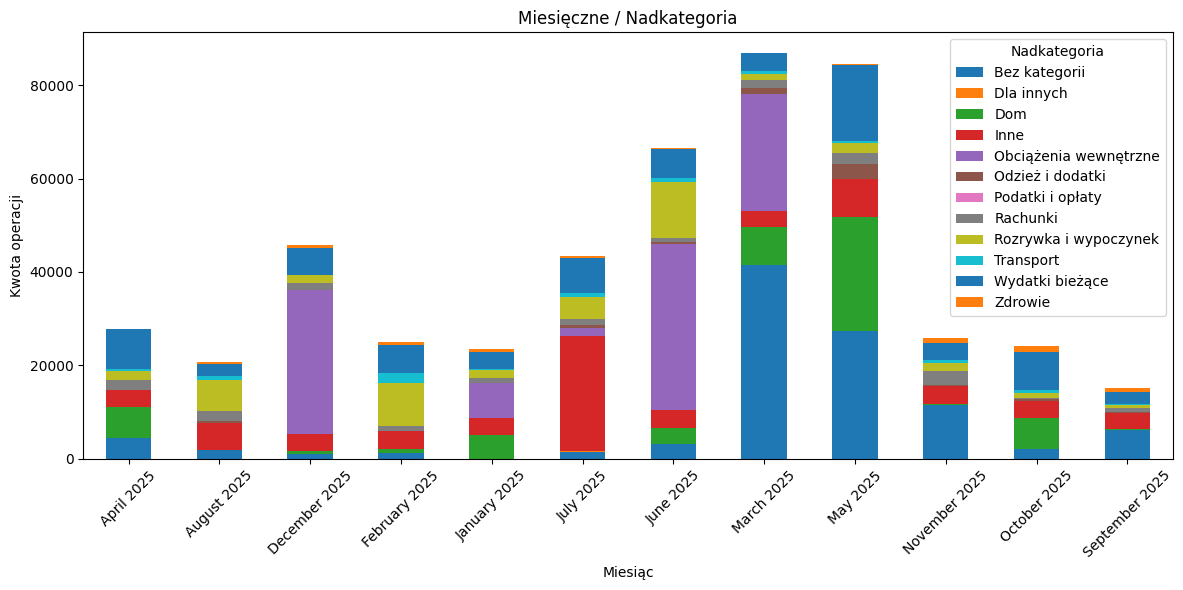

In [46]:
pivot_nad = df.pivot_table(
    index="Miesiąc",
    columns="Nadkategoria",
    values="Kwota operacji",
    aggfunc="sum"
).fillna(0)

pivot_nad.plot(kind="bar", stacked=True, figsize=(12,6))

plt.ylabel("Kwota operacji")
plt.xlabel("Miesiąc")
plt.title("Miesięczne / Nadkategoria")
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

In [47]:
monthly_cat = (
    df.groupby(["Miesiąc","Nadkategoria","Kategoria"])["Kwota operacji"]
    .sum()
    .reset_index()
)

monthly_cat["Procent"] = (
    monthly_cat
    .groupby(["Miesiąc","Nadkategoria"])["Kwota operacji"]
    .transform(lambda x: x / x.sum() * 100)
)

monthly_cat = monthly_cat.sort_values(["Miesiąc","Nadkategoria","Kwota operacji"], ascending=[True,True,False])

,Miesiąc,Nadkategoria,Kategoria,Kwota operacji,Procent
0,April 2025,Bez kategorii,Bez kategorii,4487.09,100.000000
3,April 2025,Dom,Wyposażenie,5000.00,75.183674
2,April 2025,Dom,Ogród,1549.50,23.299420
1,April 2025,Dom,Naprawy i remonty,100.88,1.516906
5,April 2025,Inne,Spłata kredytu / pożyczki,3329.76,94.575035
...,...,...,...,...,...
275,September 2025,Wydatki bieżące,Zakupy przez internet,713.75,29.298639
274,September 2025,Wydatki bieżące,Kosmetyki,71.36,2.929248
276,September 2025,Wydatki bieżące,Zwierzęta domowe,24.99,1.025812
278,September 2025,Zdrowie,Opieka medyczna,735.50,88.224357


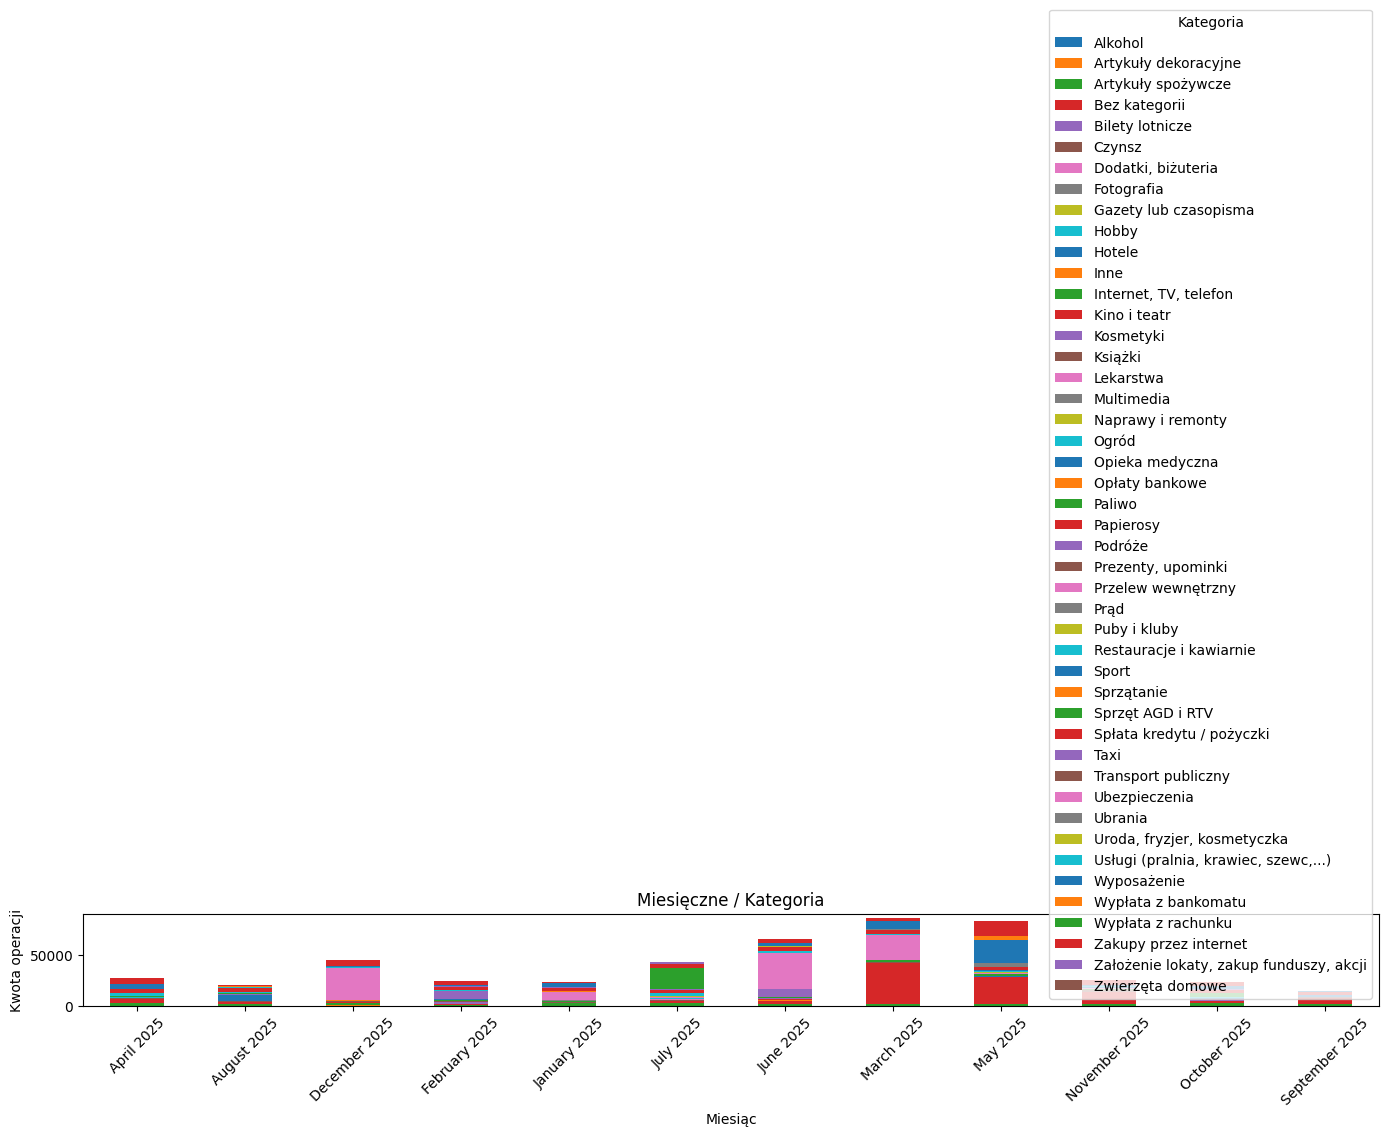

In [48]:
pivot_cat = df.pivot_table(
    index="Miesiąc",
    columns="Kategoria",
    values="Kwota operacji",
    aggfunc="sum"
).fillna(0)

pivot_cat.plot(kind="bar", stacked=True, figsize=(14,7))

plt.ylabel("Kwota operacji")
plt.xlabel("Miesiąc")
plt.title("Miesięczne / Kategoria")
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()